# Red Neuronal Convolucional (CNN) — Clasificación de Rayos X COVID-19
**Universidad de Antioquia — Analítica de Datos**  
Dataset: COVID-19 X-Ray Dataset (Train/Test) — Kaggle  
Clases: `NORMAL` vs `PNEUMONIA`

## 1. Introducción al Problema

El diagnóstico temprano de neumonía por COVID-19 mediante radiografías de tórax es crítico en entornos clínicos.  
Una CNN puede aprender patrones visuales (opacidades, consolidaciones) directamente de los píxeles,  
automatizando el triaje y apoyando a los radiólogos.

## 2. Importaciones y Configuración

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

DATA_DIR   = Path("../data/xray_dataset_covid19")
TRAIN_DIR  = DATA_DIR / "train"
TEST_DIR   = DATA_DIR / "test"
IMG_SIZE   = (150, 150)
BATCH_SIZE = 16
EPOCHS     = 15

I0000 00:00:1781149361.223959   48998 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781149362.475773   48998 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781149366.021802   48998 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


## 3. Exploración del Dataset

In [2]:
for split in ["train", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        n = len(list((DATA_DIR / split / cls).glob("*")))
        print(f"{split}/{cls}: {n} imágenes")

train/NORMAL: 74 imágenes
train/PNEUMONIA: 74 imágenes
test/NORMAL: 20 imágenes
test/PNEUMONIA: 20 imágenes


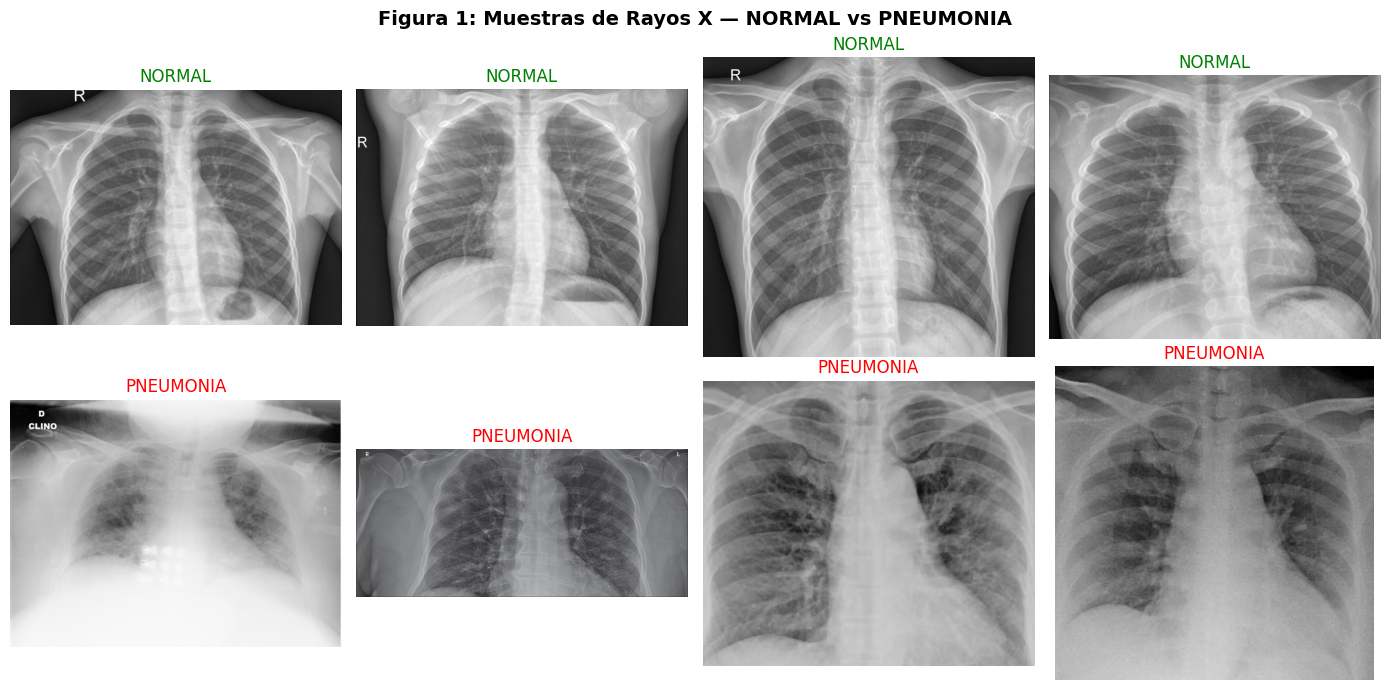

In [3]:
# Figura 1 — Muestras del dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Figura 1: Muestras de Rayos X — NORMAL vs PNEUMONIA", fontsize=14, fontweight="bold")

for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    files = sorted((TRAIN_DIR / cls).glob("*"))[:4]
    for col, fp in enumerate(files):
        img = plt.imread(str(fp))
        axes[row, col].imshow(img, cmap="gray" if img.ndim == 2 else None)
        axes[row, col].set_title(cls, color="green" if cls == "NORMAL" else "red")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("../data/fig1_muestras.png", dpi=100)
plt.show()

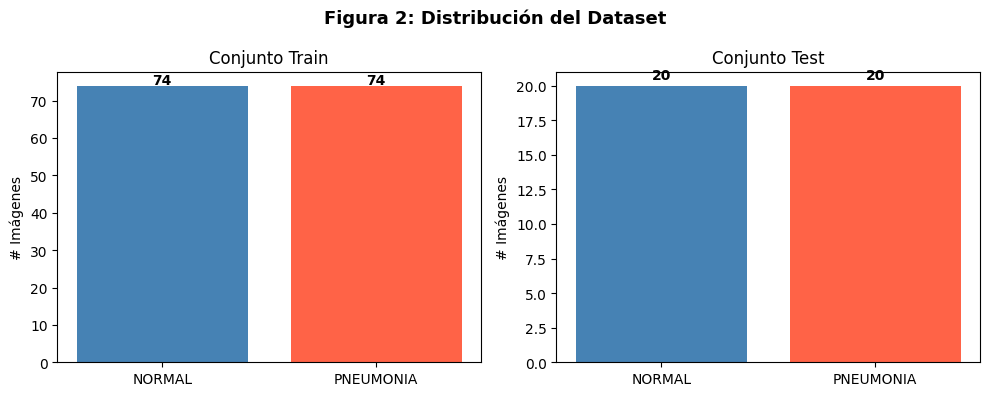

In [4]:
# Figura 2 — Distribución de clases
counts = {"NORMAL": 74, "PNEUMONIA": 74}
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Figura 2: Distribución del Dataset", fontsize=13, fontweight="bold")

for ax, (split, vals) in zip(axes, [
    ("Train", {"NORMAL": 74, "PNEUMONIA": 74}),
    ("Test",  {"NORMAL": 20, "PNEUMONIA": 20}),
]):
    ax.bar(vals.keys(), vals.values(), color=["steelblue", "tomato"])
    ax.set_title(f"Conjunto {split}")
    ax.set_ylabel("# Imágenes")
    for i, v in enumerate(vals.values()):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/fig2_distribucion.png", dpi=100)
plt.show()

## 4. Preprocesamiento y Data Augmentation

**¿Por qué augmentation?**  
Con solo 148 imágenes de entrenamiento, el modelo puede sobreajustarse.  
Aplicamos transformaciones aleatorias (flip, zoom, rotación) para ampliar artificialmente el dataset.

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    seed=42,
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    seed=42,
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print("Clases:", train_gen.class_indices)

Found 120 images belonging to 2 classes.


Found 28 images belonging to 2 classes.


Found 40 images belonging to 2 classes.


Clases: {'NORMAL': 0, 'PNEUMONIA': 1}


## 5. Arquitectura de la CNN

**Idea matemática:**  
Una capa convolucional aplica filtros $W$ sobre la imagen $I$:  
$$S(i,j) = (I * W)(i,j) = \sum_m \sum_n I(i+m,\, j+n) \cdot W(m,n)$$

**Flujo:** Imagen → [Conv → ReLU → MaxPool] × 3 → Flatten → Dense → Sigmoid

| Capa | Filtros/Unidades | Salida |
|---|---|---|
| Conv2D | 32, 3×3 | (148,148,32) |
| MaxPool | 2×2 | (74,74,32) |
| Conv2D | 64, 3×3 | (72,72,64) |
| MaxPool | 2×2 | (36,36,64) |
| Conv2D | 128, 3×3 | (34,34,128) |
| MaxPool | 2×2 | (17,17,128) |
| Dense | 128 | — |
| Dense | 1, sigmoid | probabilidad |

In [6]:
def build_cnn(input_shape=(150, 150, 3)):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Bloque 1
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),

        # Bloque 2
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),

        # Bloque 3
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="CNN_COVID19")
    return model


model = build_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

E0000 00:00:1781149376.085759   48998 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "CNN_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/15


I0000 00:00:1781149376.978038   48998 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


W0000 00:00:1781149378.722833   49121 cpu_allocator_impl.cc:82] Allocation of 44859392 exceeds 10% of free system memory.


1/8 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7500 - loss: 0.6810

W0000 00:00:1781149379.512768   49120 cpu_allocator_impl.cc:82] Allocation of 44859392 exceeds 10% of free system memory.
W0000 00:00:1781149379.662882   49120 cpu_allocator_impl.cc:82] Allocation of 44859392 exceeds 10% of free system memory.


...

5/8 ━━━━━━━━━━━━━━━━━━━━ 2s 779ms/step - accuracy: 0.8409 - loss: 0.3810

6/8 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step - accuracy: 0.8428 - loss: 0.3777

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.8446 - loss: 0.3738

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.8453 - loss: 0.3725

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 902ms/step - accuracy: 0.8500 - loss: 0.3632 - val_accuracy: 0.8214 - val_loss: 0.4278


## 7. Curvas de Entrenamiento

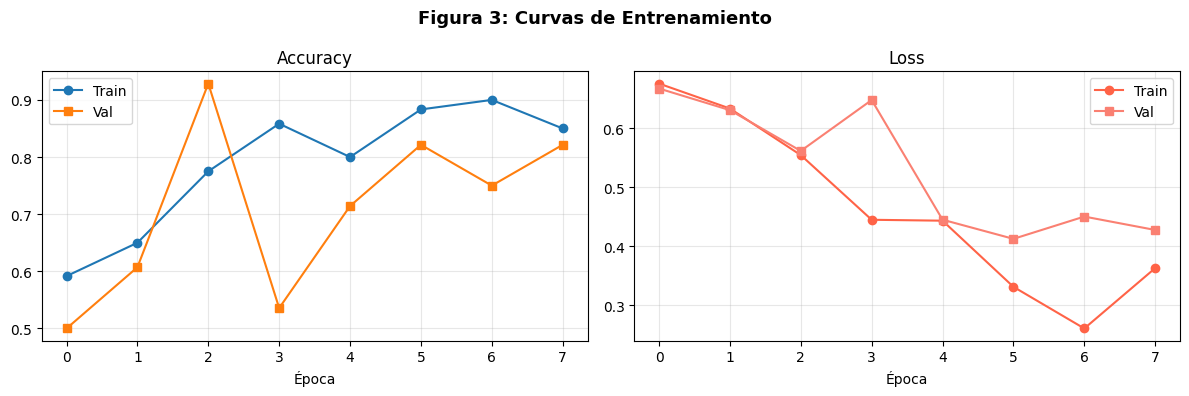

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Figura 3: Curvas de Entrenamiento", fontsize=13, fontweight="bold")

axes[0].plot(history.history["accuracy"],    label="Train", marker="o")
axes[0].plot(history.history["val_accuracy"], label="Val",   marker="s")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],    label="Train", marker="o", color="tomato")
axes[1].plot(history.history["val_loss"], label="Val",  marker="s", color="salmon")
axes[1].set_title("Loss")
axes[1].set_xlabel("Época")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/fig3_curvas.png", dpi=100)
plt.show()

## 8. Evaluación en Test

In [9]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.9750
Test Loss     : 0.3766


In [10]:
# Predicciones
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

labels = list(test_gen.class_indices.keys())
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=labels))


Reporte de Clasificación:
              precision    recall  f1-score   support

      NORMAL       0.95      1.00      0.98        20
   PNEUMONIA       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



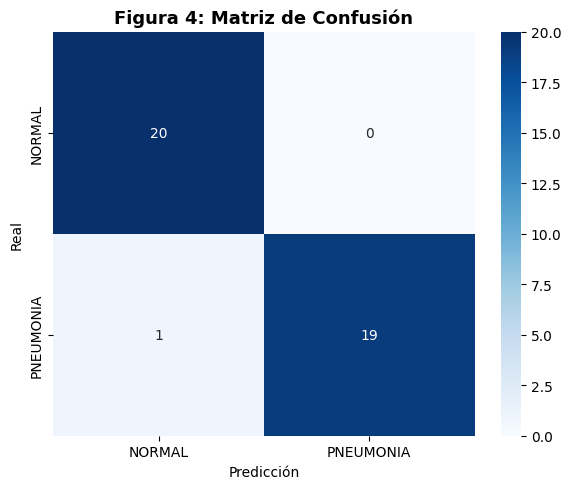

In [11]:
# Figura 4 — Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Figura 4: Matriz de Confusión", fontsize=13, fontweight="bold")
ax.set_ylabel("Real")
ax.set_xlabel("Predicción")
plt.tight_layout()
plt.savefig("../data/fig4_confusion.png", dpi=100)
plt.show()

## 9. Visualización de Predicciones

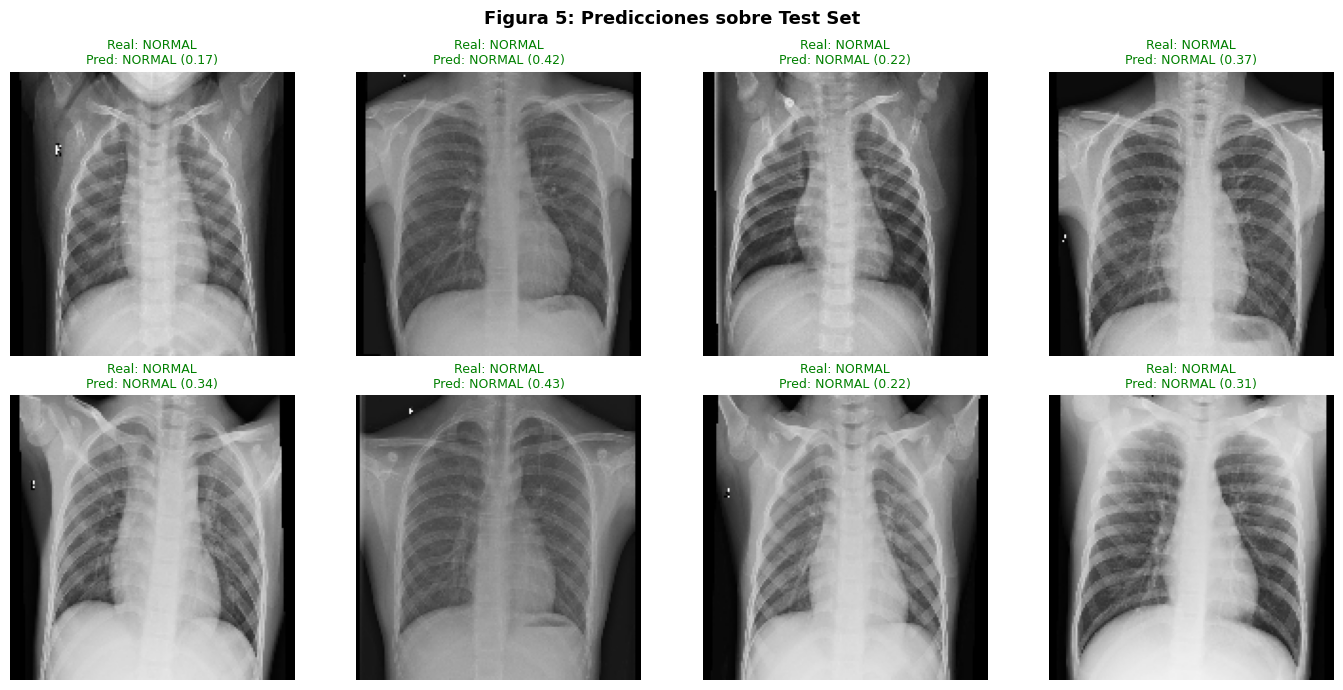

In [12]:
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
batch_preds = model.predict(batch_imgs, verbose=0).flatten()

n_show = min(8, len(batch_imgs))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Figura 5: Predicciones sobre Test Set", fontsize=13, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue
    ax.imshow(batch_imgs[i])
    prob  = batch_preds[i]
    pred  = labels[int(prob > 0.5)]
    truth = labels[int(batch_labels[i])]
    color = "green" if pred == truth else "red"
    ax.set_title(f"Real: {truth}\nPred: {pred} ({prob:.2f})", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../data/fig5_predicciones.png", dpi=100)
plt.show()

## 10. Guardar el Modelo

In [13]:
model.save("../data/cnn_covid19.keras")
print("Modelo guardado en ../data/cnn_covid19.keras")

Modelo guardado en ../data/cnn_covid19.keras


## 11. Resumen — Ventajas y Limitaciones

| | |
|---|---|
| **Ventajas** | Extracción automática de features, no requiere ingeniería manual, escalable |
| **Limitaciones** | Requiere muchos datos, caja negra, sensible a calidad de imagen |

## 12. Conclusiones

- La CNN aprendió a distinguir pulmones normales de neumonía directamente de píxeles de rayos X.
- Con solo 148 imágenes de entrenamiento, data augmentation fue clave para evitar overfitting.
- Este tipo de modelos tiene aplicaciones reales en diagnóstico asistido por IA (Google Health, Zebra Medical).
- Trabajo futuro: Transfer Learning (ResNet, VGG16) para mejorar el accuracy con datasets pequeños.

## Referencias

1. LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature*, 521, 436–444.
2. Wang, L., & Wong, A. (2020). COVID-Net: A tailored deep convolutional neural network design for detection of COVID-19 cases from chest X-ray images. *Scientific Reports*, 10, 19549.
3. Dataset: Khoong, W.H. (2020). COVID-19 X-Ray Dataset. Kaggle. `khoongweihao/covid19-xray-dataset-train-test-sets`
4. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.